In [1]:
from typing import List, Dict, Any
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain_mcp_adapters.client import MultiServerMCPClient


In [ ]:
http_server_config = {
    "current_time": {
        "url": "http://127.0.0.1:8002/mcp",
        "transport": "streamable_http",
    },
}

server_configs = {
    "weather": {
        "command": "uv",
        "args": ["run", "python", "server/mcp_server_local.py"],
        "transport": "stdio",
    },
}


In [2]:
# MultiServerMCPClient 설정 예제
async def setup_mcp_client(server_configs: List[Dict[str, Any]]):
    """MCP 클라이언트를 설정하고 도구를 가져옵니다."""

    # MCP 클라이언트 생성
    client = MultiServerMCPClient(server_configs)

    # 도구 가져오기
    tools = await client.get_tools()

    print(f"✅ {len(tools)} 개의 MCP 도구가 로드되었습니다:")
    for tool in tools:
        print(f"  - {tool.name}")

    return client, tools

In [ ]:
# # 서버 구성 정의
# server_configs = {
#     "weather": {
#         "command": "uv",
#         "args": ["run", "python", "server/mcp_server_local.py"],
#         "transport": "stdio",
#     },
# }

# # MCP 클라이언트 생성
# client, tools = await setup_mcp_client(server_configs=server_configs)

UnsupportedOperation: fileno

In [ ]:
# # LLM 설정
# llm = ChatOpenAI(model="gpt-4.1", temperature=0)

# # React Agent 생성
# agent = create_react_agent(
#     llm, tools, checkpointer=InMemorySaver()  # 상태 저장을 위한 체크포인터
# )

In [ ]:
# from langchain_teddynote.messages import astream_graph, random_uuid
# from langchain_core.runnables import RunnableConfig

# config = RunnableConfig(configurable={"thread_id": random_uuid()})

# response = await astream_graph(
#     agent,
#     inputs={"messages": [("human", "안녕하세요. 서울의 날씨를 알려주세요.")]},
#     config=config,
# )

## Part 4: React Agent와 MCP 통합

React Agent는 추론(Reason)과 행동(Act)을 반복하는 패턴을 구현합니다. MCP 도구와 함께 사용하면 강력한 에이전트를 만들 수 있습니다.

In [4]:
async def create_mcp_react_agent(server_configs: dict):
    """MCP 도구를 사용하는 React Agent를 생성합니다."""

    # MCP 클라이언트 생성 및 도구 가져오기
    client, tools = await setup_mcp_client(server_configs=server_configs)

    # LLM 설정
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    # React Agent 생성
    agent = create_react_agent(
        llm, tools, checkpointer=InMemorySaver()  # 상태 저장을 위한 체크포인터
    )

    return agent

In [12]:
# MCP 서버 Config 설정
server_configs = {
    # "weather": {
    #     "command": "uv",
    #     "args": ["run", "python", "server/mcp_server_local.py"],
    #     "transport": "stdio",
    # },
    "current_time": {
        "url": "http://127.0.0.1:8002/mcp",
        "transport": "streamable_http",
    },
}

# MCP ReAct Agent 생성
agent = await create_mcp_react_agent(server_configs)

✅ 1 개의 MCP 도구가 로드되었습니다:
  - get_current_time


C:\Users\skyop\AppData\Local\Temp\ipykernel_3412\2221520254.py:11: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [6]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import random_uuid, astream_graph


config = RunnableConfig(configurable={"thread_id": random_uuid()})

# await astream_graph(
#     agent, inputs={"messages": [("human", "현재 시간을 알려주세요")]}, config=config
# )

await astream_graph(
    agent,
    inputs={"messages": [("human", "현재 서울의 날씨도 알려주세요")]},
    config=config,
)


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Current time in Asia/Seoul is: 2025-11-05 00:48:54 KST
🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
현재 서울의 시간은 2025년 11월 5일 00시 48분 54초입니다. 날씨 정보는 제공되지 않지만, 서울의 날씨를 확인하려면 기상청 웹사이트나 날씨 앱을 참고하시기 바랍니다.

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--3df28dd5-78de-44df-ab74-57a69e074832', chunk_position='last'),
 'metadata': {'thread_id': '92c9c2d5-b9ed-4595-b2f2-269bb8570020',
  'langgraph_step': 3,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent',),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:f11a9799-577e-8bf8-0707-d7f7c04348e3',
  'checkpoint_ns': 'agent:f11a9799-577e-8bf8-0707-d7f7c04348e3',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4o-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'revision_id': '3562c6b-dirty'}}

## Part 5: ToolNode와 MCP 통합

ToolNode를 사용하면 더 세밀한 제어가 가능한 커스텀 워크플로우를 만들 수 있습니다.

In [7]:
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_teddynote.graphs import visualize_graph
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from typing import Annotated, List, Dict, Any
from langchain_openai import ChatOpenAI
from typing import TypedDict
from langchain_tavily import TavilySearch


# 상태 정의
class AgentState(TypedDict):
    """에이전트 상태"""

    messages: Annotated[List[BaseMessage], add_messages]
    context: Dict[str, Any] = None  # 추가 컨텍스트 정보


async def create_mcp_workflow(server_configs: dict):
    """MCP 도구를 사용하는 커스텀 워크플로우 생성"""

    # MCP 클라이언트 생성
    client, tools = await setup_mcp_client(server_configs=server_configs)

    # Tavily 검색 도구 추가
    tool = TavilySearch(max_results=2)
    tools.append(tool)

    # LLM 설정 (도구 바인딩)
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    llm_with_tools = llm.bind_tools(tools)

    # 워크플로우 그래프 생성
    workflow = StateGraph(AgentState)

    # 노드 정의
    async def agent_node(state: AgentState):
        """LLM을 호출하여 응답 생성"""
        response = await llm_with_tools.ainvoke(state["messages"])
        return {"messages": [response]}

    # ToolNode 생성
    tool_node = ToolNode(tools)

    # 그래프 구성
    workflow.add_node("agent", agent_node)
    workflow.add_node("tools", tool_node)

    workflow.add_edge(START, "agent")
    workflow.add_conditional_edges("agent", tools_condition)
    workflow.add_edge("tools", "agent")
    workflow.add_edge("agent", END)

    # 컴파일
    app = workflow.compile(checkpointer=InMemorySaver())

    visualize_graph(app)

    return app

In [8]:
# MCP 서버 Config 설정
server_configs = {
    # "weather": {
    #     "command": "uv",
    #     "args": ["run", "python", "server/mcp_server_local.py"],
    #     "transport": "stdio",
    # },
    "current_time": {
        "url": "http://127.0.0.1:8002/mcp",
        "transport": "streamable_http",
    },
}

✅ 1 개의 MCP 도구가 로드되었습니다:
  - get_current_time


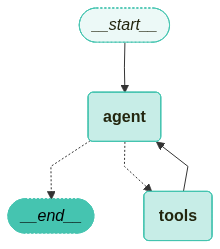

In [9]:
mcp_app = await create_mcp_workflow(server_configs)

In [10]:
_ = await astream_graph(
    mcp_app, inputs={"messages": [("human", "현재 시간을 알려주세요")]}, config=config
)


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Current time in Asia/Seoul is: 2025-11-05 00:49:54 KST
🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
현재 서울 시간 기준으로 2025년 11월 5일 00시 49분 54초입니다.

In [11]:
_ = await astream_graph(
    mcp_app,
    inputs={
        "messages": [
            ("human", "오늘 뉴스를 검색해주세요. 검색시 시간을 조회한 뒤 처리하세요.")
        ]
    },
    config=config,
)


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Current time in Asia/Seoul is: 2025-11-05 00:49:57 KST{"query": "오늘 뉴스", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/politics/2025/11/04/whats-ballot-today/", "title": "Analysis | What’s on the ballot today? - The Washington Post", "score": 0.22735819, "published_date": "Tue, 04 Nov 2025 11:00:29 GMT", "content": "Democracy Dies in Darkness Early Brief # What’s on the ballot today? 9 min Analysis by Matthew Choi Dan Merica **In today’s edition** … New Jersey and Virginia have major governors’ races … New York City decides its next mayor … Democrats’ biggest redistricting push hits the ballot … ## It’s Election Day. Michael Kranish Jefferson’s paradox: How one of the largest slaveholders penned the words “All men are created equal” Christine Mi 7 nights at sea aboard the last grand ocean